# ✈️ Flight Delay Prediction Project

## 🎯 Goal
Predict whether a flight will be **Delayed** 🕒 or **On-Time** ✅ using pre-flight information.

In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [45]:
df=pd.read_csv(r"D:\NTI - ML\Flight_Status\Flight_Status.csv")
df.head()

,Unnamed: 0,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Airlines,OriginCityName,DestCityName,DepDelay,ArrDelay,AirTime,Distance,Month_Str,DayOfWeek_Str,Flight_Status
0,1,1,1,6,4,2022-01-06,Delta Airlines,"Atlanta, GA","Fort Lauderdale, FL",-4.0,-1.0,93.0,581.0,Jan,Thu,0
1,2,1,1,6,4,2022-01-06,Delta Airlines,"Fort Lauderdale, FL","Atlanta, GA",-2.0,-12.0,83.0,581.0,Jan,Thu,0
2,3,1,1,6,4,2022-01-06,Delta Airlines,"Fort Lauderdale, FL","Raleigh/Durham, NC",-5.0,-15.0,93.0,680.0,Jan,Thu,0
3,4,1,1,6,4,2022-01-06,Delta Airlines,"Atlanta, GA","Jackson/Vicksburg, MS",-4.0,-11.0,60.0,341.0,Jan,Thu,0
4,5,1,1,6,4,2022-01-06,Delta Airlines,"Jackson/Vicksburg, MS","Atlanta, GA",-7.0,-23.0,49.0,341.0,Jan,Thu,0


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6804006 entries, 0 to 6804005
Data columns (total 16 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Unnamed: 0      int64  
 1   Quarter         int64  
 2   Month           int64  
 3   DayofMonth      int64  
 4   DayOfWeek       int64  
 5   FlightDate      object 
 6   Airlines        object 
 7   OriginCityName  object 
 8   DestCityName    object 
 9   DepDelay        float64
 10  ArrDelay        float64
 11  AirTime         float64
 12  Distance        float64
 13  Month_Str       object 
 14  DayOfWeek_Str   object 
 15  Flight_Status   int64  
dtypes: float64(4), int64(6), object(6)
memory usage: 830.6+ MB


| #  | Column Name    | Data Type | Description                                                             |
| -- | -------------- | --------- | ----------------------------------------------------------------------- |
| 0  | Unnamed: 0     | int64     | Index column (رقم الصف في الداتا سيت، غالبًا ملوش معنى تحليلي).         |
| 1  | Quarter        | int64     | الربع السنوي (1 إلى 4) اللي حصلت فيه الرحلة.                            |
| 2  | Month          | int64     | رقم الشهر (1 = يناير، 12 = ديسمبر).                                     |
| 3  | DayofMonth     | int64     | رقم اليوم في الشهر (1–31).                                              |
| 4  | DayOfWeek      | int64     | رقم اليوم في الأسبوع (1–7).                                             |
| 5  | FlightDate     | object    | تاريخ الرحلة كامل (عادة بصيغة YYYY-MM-DD).                              |
| 6  | Airlines       | object    | اسم شركة الطيران اللي شغلت الرحلة.                                      |
| 7  | OriginCityName | object    | المدينة اللي أقلعت منها الرحلة.                                         |
| 8  | DestCityName   | object    | المدينة اللي وصلت إليها الرحلة.                                         |
| 9  | DepDelay       | float64   | مدة تأخير الإقلاع بالدقائق (لو سالب يبقى أقلعت بدري).                   |
| 10 | ArrDelay       | float64   | مدة تأخير الوصول بالدقائق (لو سالب يبقى وصلت بدري).                     |
| 11 | AirTime        | float64   | مدة الطيران الفعلية في الجو بالدقائق.                                   |
| 12 | Distance       | float64   | المسافة بين المدينتين (عادة بالميل).                                    |
| 13 | Month_Str      | object    | اسم الشهر كنص (مثلاً January بدل 1).                                    |
| 14 | DayOfWeek_Str  | object    | اسم اليوم كنص (مثلاً Monday بدل 1).                                     |
| 15 | Flight_Status  | int64     | حالة الرحلة (غالبًا 0 = في الميعاد، 1 = متأخرة — حسب تعريف الداتا سيت). |


# Preprocessing 🧹

In [47]:
df.shape

(6804006, 16)

In [48]:
df.duplicated().sum()

np.int64(0)

# Visualization🎨

## Flight_Status Class Distribution

Bar plot showing the target variable `Flight_Status`.  

- **0:** On-time  
- **1:** Delayed  

The dataset is **imbalanced**, with more on-time flights than delayed ones.


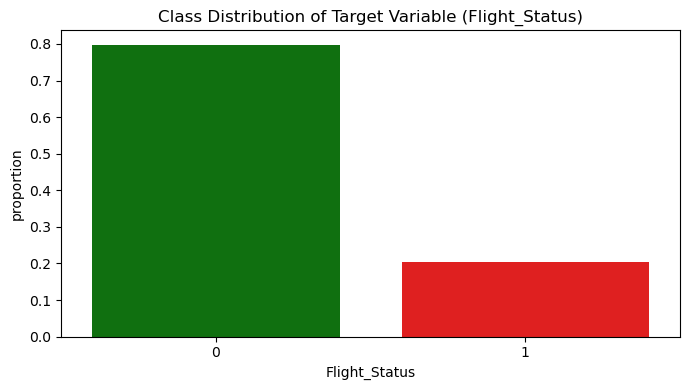

In [49]:
plt.figure(figsize=(7,4))
sns.barplot(df['Flight_Status'].value_counts(normalize=True),palette=['green', 'red'] )
plt.title("Class Distribution of Target Variable (Flight_Status)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Airline Delay Analysis

After analyzing the delay rate across airlines, we found that the highest delay rates were observed for:

- **JetBlue Airways**
- **Frontier Airlines**
- **Allegiant Air**

### 🔎 Interpretation

These airlines show a higher proportion of delayed flights compared to others in the dataset.

Possible explanations include:

- Operational efficiency differences
- Fleet size and aircraft availability
- Route structures (e.g., serving congested airports)
- Higher exposure to seasonal or high-traffic routes
- Cost-control strategies that may reduce schedule flexibility

📌 This indicates that airline choice is an important predictive factor for flight delays.

---

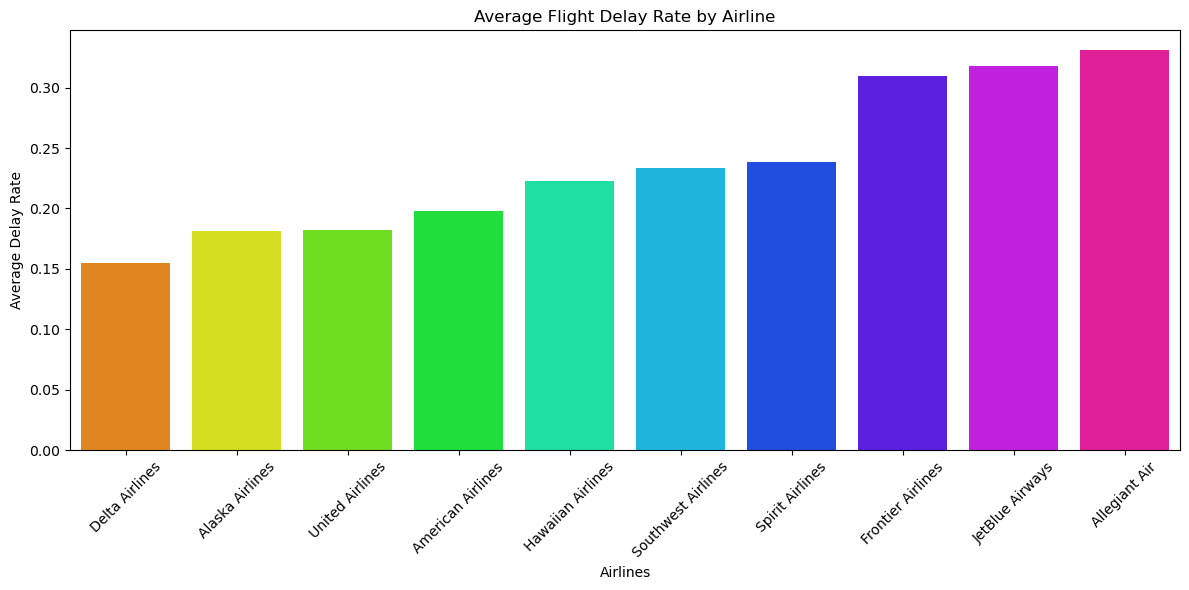

In [50]:
plt.figure(figsize=(12,6))
sns.barplot(df.groupby('Airlines')['Flight_Status'].mean().sort_values(),palette="hsv")

plt.title("Average Flight Delay Rate by Airline")
plt.xlabel("Airlines")
plt.ylabel("Average Delay Rate")
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()


## Monthly Delay Analysis

**After analyzing the delay rate by month, we observed that:** 

- **June (Month 6)** has one of the highest delay rates.
- **December (Month 12)** also shows a significant increase in delays.

### 🔎 Interpretation

- **June**:
  - The beginning of the summer season
  - Increased travel demand (school vacations, tourism)
  - Higher airport congestion

- **December**:
  - Holiday season
  - Increased domestic and international travel
  - Possible weather-related disruptions (winter conditions)

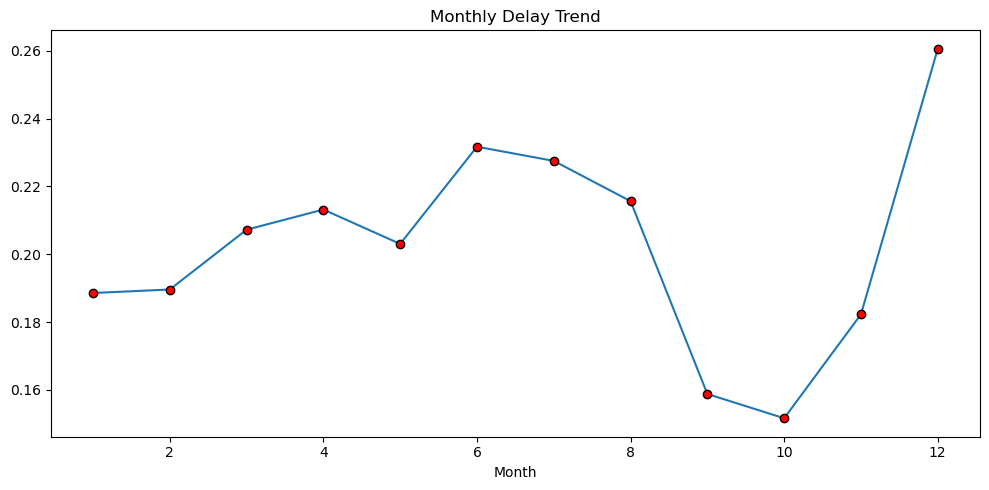

In [51]:
plt.figure(figsize=(10,5))
df.groupby('Month')['Flight_Status'].mean().plot(marker='o',markerfacecolor='red', markeredgecolor='black')
plt.title("Monthly Delay Trend")
plt.tight_layout()
plt.show()

## Day of Week Delay Analysis

**The highest delay rates were observed on:**

- **Day 5**
- **Day 7**

(Assuming 5 = Friday and 7 = Sunday)

### 🔎 Interpretation

- **Friday**:
  - Beginning of the weekend
  - Increased outbound travel demand

- **Sunday**:
  - Peak return travel day
  - Higher airport traffic congestion

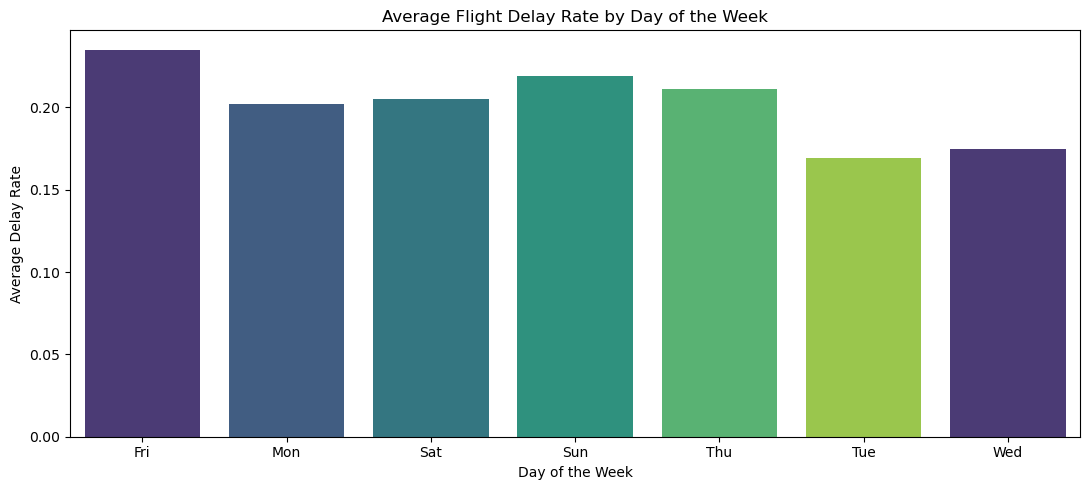

In [52]:
plt.figure(figsize=(11,5))

delay_rates = df.groupby('DayOfWeek_Str')['Flight_Status'].mean().reset_index()
sns.barplot(
    x='DayOfWeek_Str',
    y='Flight_Status',
    data=delay_rates,
    palette = sns.color_palette("viridis")   
)
plt.title("Average Flight Delay Rate by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Delay Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

--------

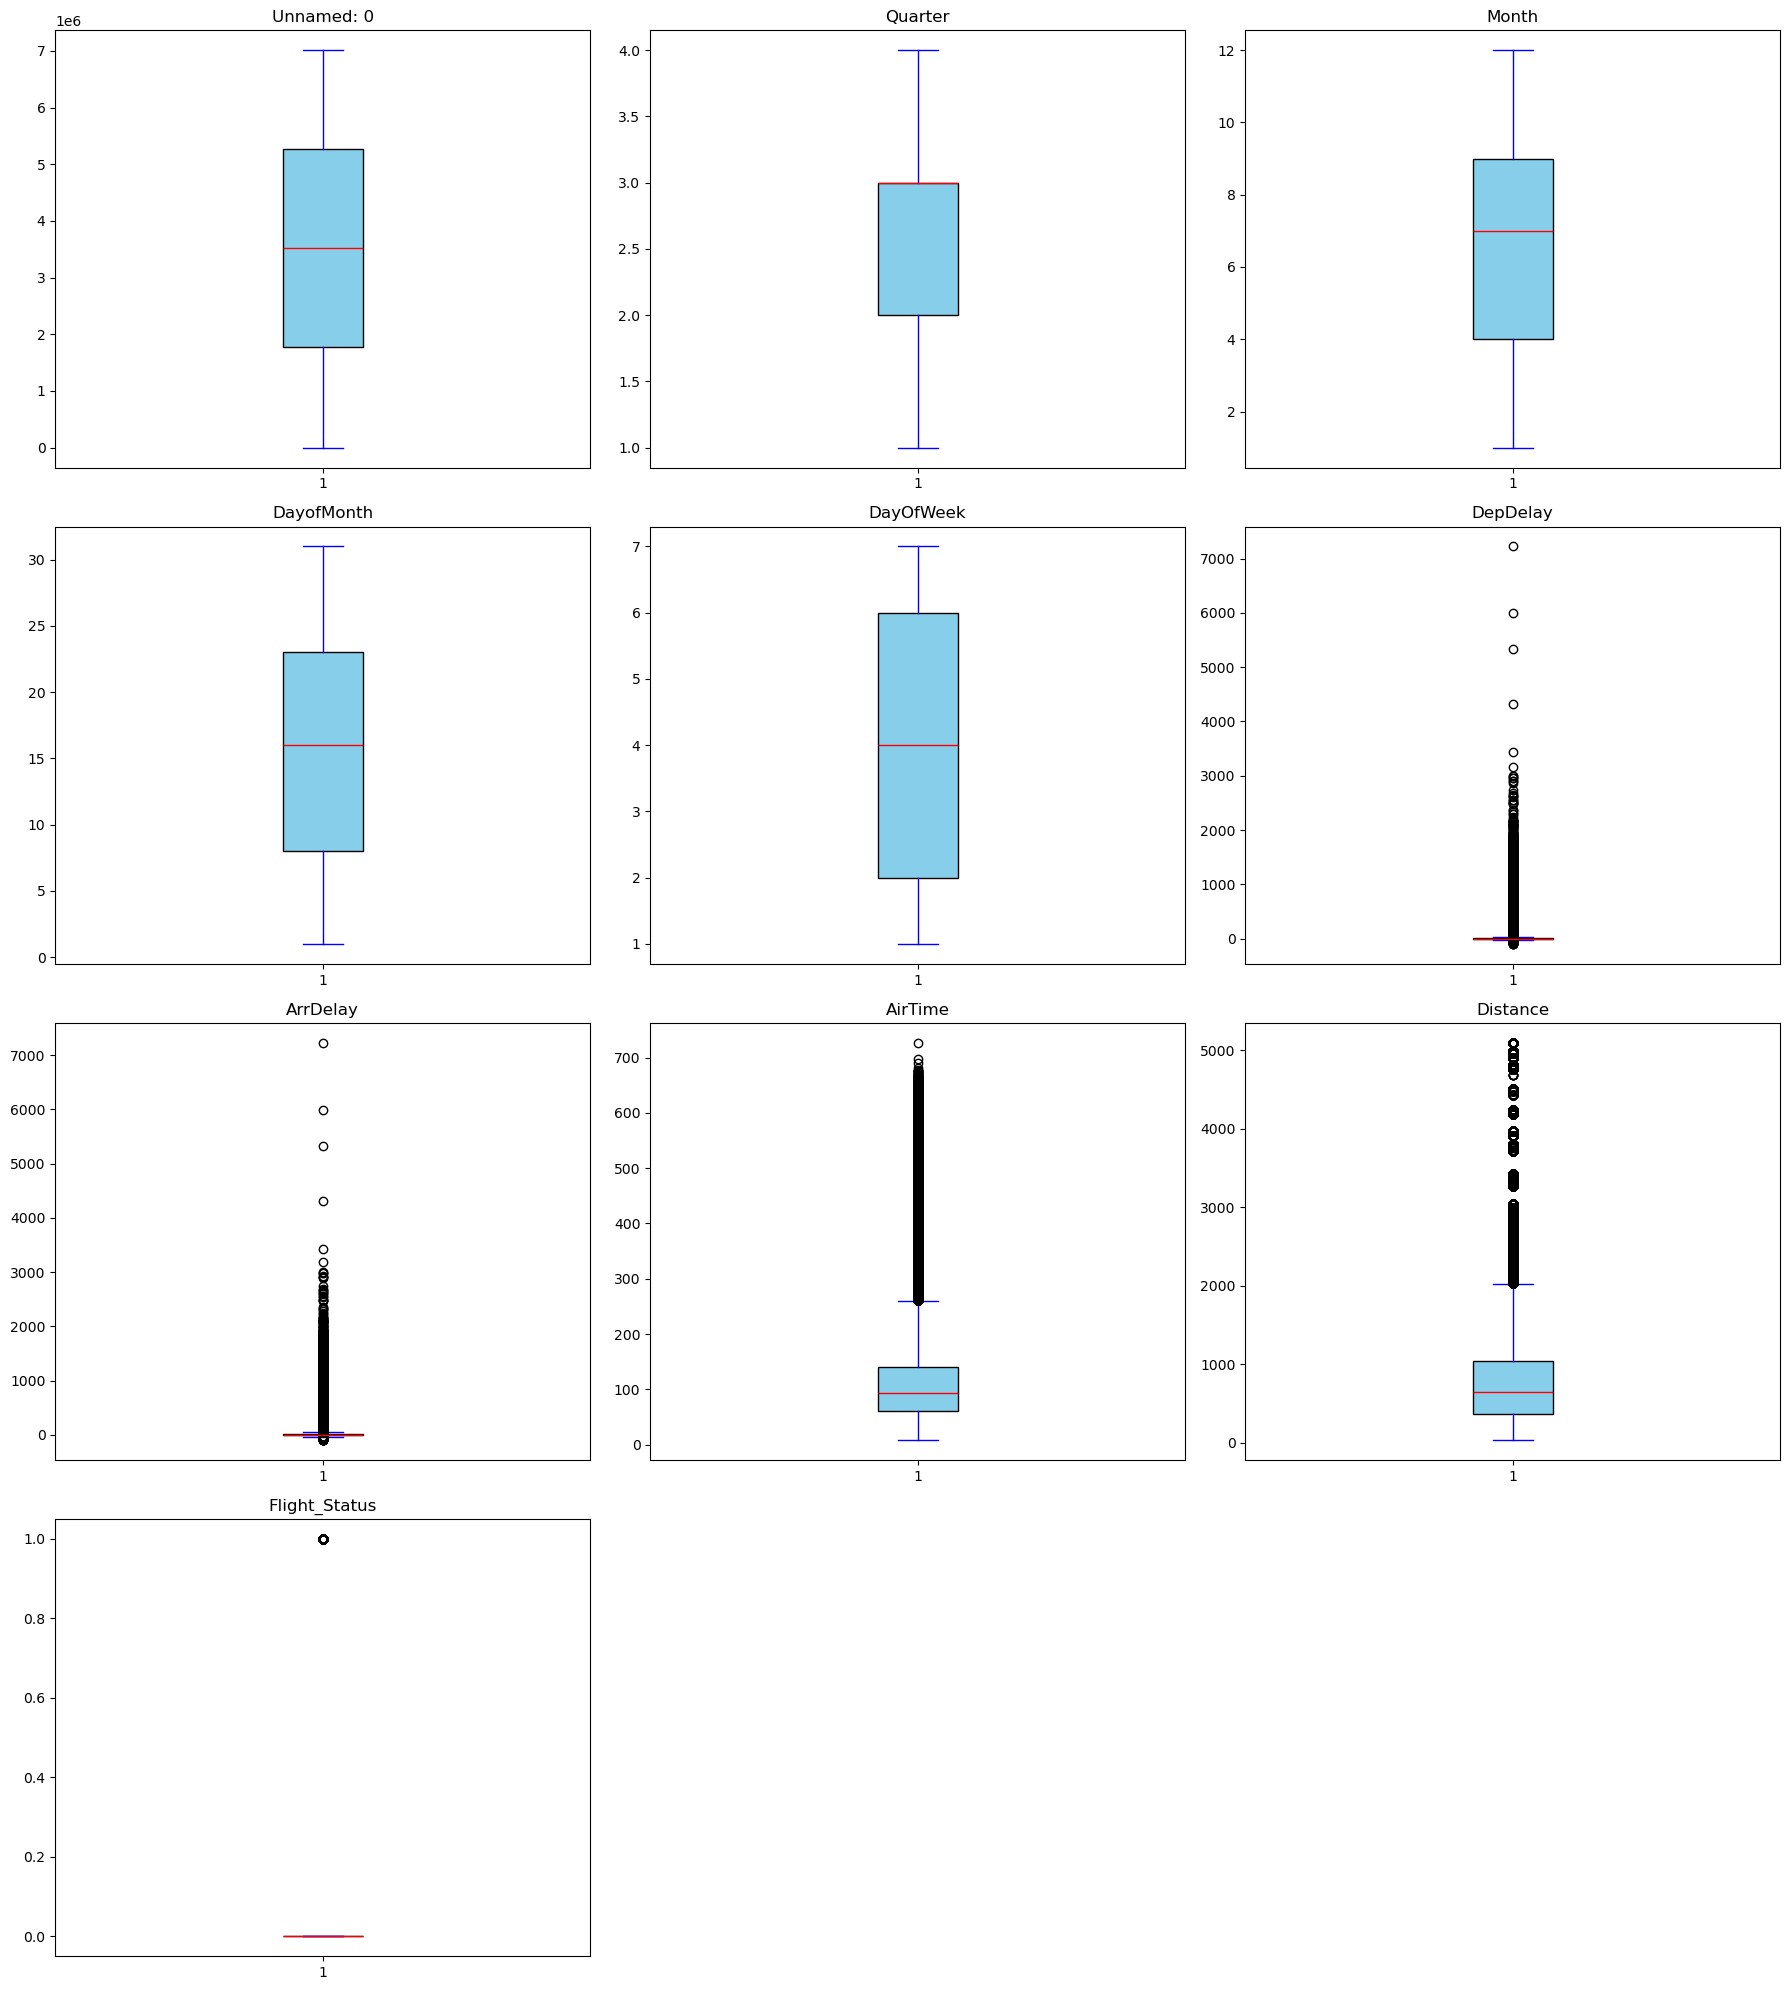

In [53]:
num_cols = df.select_dtypes(include=np.number).columns

n_cols = 3   
n_rows = int(np.ceil(len(num_cols) / n_cols))

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.boxplot(df[col], vert=True,patch_artist=True,       
            boxprops=dict(facecolor='skyblue', color='black'),   
            medianprops=dict(color='red'),                     
            whiskerprops=dict(color='blue'),                   
            capprops=dict(color='blue'))
    plt.title(col)
    plt.tight_layout()

plt.show()


## This visualization helps to identify patterns such as:
- Which months have higher delay rates  
- Which days of the week are more prone to delays  
- Possible seasonal trends in flight delays

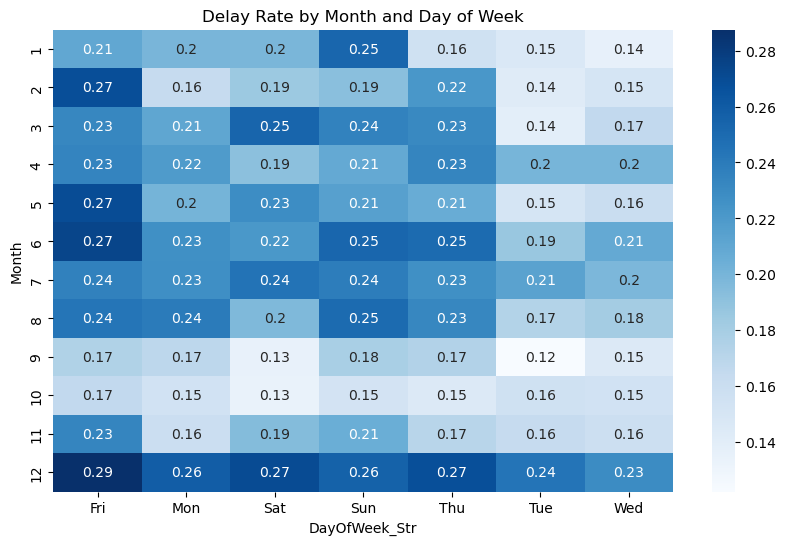

In [54]:
pivot = df.pivot_table(values='Flight_Status',
                       index='Month',
                       columns='DayOfWeek_Str',
                       aggfunc='mean')


plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap='Blues')
plt.title("Delay Rate by Month and Day of Week")
plt.show()


## This visualization helps to identify patterns such as:
- Which distances are more common  
- Whether delayed flights tend to occur on longer or shorter flights 

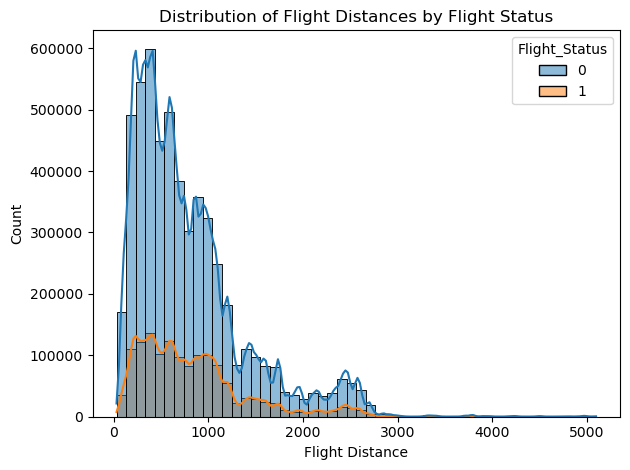

In [55]:
sns.histplot(data=df, x='Distance', hue='Flight_Status', bins=50, kde=True)
plt.title("Distribution of Flight Distances by Flight Status")
plt.xlabel("Flight Distance")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


****
                                                                     :(0__0):
****

## Drop The columns are not important

In [56]:
cols_to_drop = ['ArrDelay', 'DepDelay', 'AirTime', 
                'Month_Str', 'DayOfWeek_Str', 
                'Unnamed: 0']
                
df.drop(columns=cols_to_drop,axis=1,inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6804006 entries, 0 to 6804005
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Quarter         int64  
 1   Month           int64  
 2   DayofMonth      int64  
 3   DayOfWeek       int64  
 4   FlightDate      object 
 5   Airlines        object 
 6   OriginCityName  object 
 7   DestCityName    object 
 8   Distance        float64
 9   Flight_Status   int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 519.1+ MB


In [57]:
df.duplicated().sum()

np.int64(3495173)

In [58]:
df.isna().sum()

Quarter           0
Month             0
DayofMonth        0
DayOfWeek         0
FlightDate        0
Airlines          0
OriginCityName    0
DestCityName      0
Distance          0
Flight_Status     0
dtype: int64

### IsWeekend 🎉 → 1 if flight on weekend, 0 otherwise

In [59]:
#  DayOfWeek 6 = Saturday || 7 = Sunday
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x in [6,7] else 0)


## ✈️ Airline Historical Delay Rate

**Column:** `Airline_History_Delay`  

- Represents the **historical average delay rate** of each airline.  
- Values are **between 0 and 1**:
  - `0` → Airline historically has no delays  
  - `1` → Airline historically delays every flight  
- Each flight row gets the value corresponding to its airline.  

**Example:**
- JetBlue Airways: 0.30 → 30% of its flights were delayed historically  
- Allegiant Air: 0.10 → 10% of its flights were delayed historically  

This feature helps the model understand which airlines are more likely to delay flights.

In [60]:
airline_delay_rate = df.groupby('Airlines')['Flight_Status'].mean()
df['Airline_History_Delay'] = df['Airlines'].map(airline_delay_rate)

## Peak month indicator 🌟

In [61]:
peak_months = [6, 12]  # June & December
df['Is_Peak_Month'] = df['Month'].isin(peak_months).astype(int)

## Season 🌦️

In [62]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)


## Convert the 'Month' column into cyclical features 🔄
## This helps the model understand that December (12) is close to January (1)

In [63]:

df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)


## Cyclical encoding for 'DayOfWeek'🔄
## This helps the model understand that Sunday (7) is close to Monday (1)


In [64]:
df['DayOfWeek_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['DayOfWeek_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)


In [65]:
df = df.drop(columns=['Month', 'DayOfWeek'])

In [66]:
df.head()

,Quarter,DayofMonth,FlightDate,Airlines,OriginCityName,DestCityName,Distance,Flight_Status,IsWeekend,Airline_History_Delay,Is_Peak_Month,Season,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos
0,1,6,2022-01-06,Delta Airlines,"Atlanta, GA","Fort Lauderdale, FL",581.0,0,0,0.154771,0,Winter,0.5,0.866025,-0.433884,-0.900969
1,1,6,2022-01-06,Delta Airlines,"Fort Lauderdale, FL","Atlanta, GA",581.0,0,0,0.154771,0,Winter,0.5,0.866025,-0.433884,-0.900969
2,1,6,2022-01-06,Delta Airlines,"Fort Lauderdale, FL","Raleigh/Durham, NC",680.0,0,0,0.154771,0,Winter,0.5,0.866025,-0.433884,-0.900969
3,1,6,2022-01-06,Delta Airlines,"Atlanta, GA","Jackson/Vicksburg, MS",341.0,0,0,0.154771,0,Winter,0.5,0.866025,-0.433884,-0.900969
4,1,6,2022-01-06,Delta Airlines,"Jackson/Vicksburg, MS","Atlanta, GA",341.0,0,0,0.154771,0,Winter,0.5,0.866025,-0.433884,-0.900969


In [67]:
# chek duplicated
df.duplicated().sum()

np.int64(3495173)

In [68]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True,inplace=True)

In [69]:
df.duplicated().sum()


np.int64(0)

In [70]:
df.shape

(3308833, 16)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3308833 entries, 0 to 3308832
Data columns (total 16 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Quarter                int64  
 1   DayofMonth             int64  
 2   FlightDate             object 
 3   Airlines               object 
 4   OriginCityName         object 
 5   DestCityName           object 
 6   Distance               float64
 7   Flight_Status          int64  
 8   IsWeekend              int64  
 9   Airline_History_Delay  float64
 10  Is_Peak_Month          int64  
 11  Season                 object 
 12  Month_sin              float64
 13  Month_cos              float64
 14  DayOfWeek_sin          float64
 15  DayOfWeek_cos          float64
dtypes: float64(6), int64(5), object(5)
memory usage: 403.9+ MB


In [72]:
df['Year'] = pd.to_datetime(df['FlightDate']).dt.year
df['Year'].unique()

array([2022], dtype=int32)

In [73]:
df.head()

,Quarter,DayofMonth,FlightDate,Airlines,OriginCityName,DestCityName,Distance,Flight_Status,IsWeekend,Airline_History_Delay,Is_Peak_Month,Season,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos,Year
0,1,6,2022-01-06,Delta Airlines,"Atlanta, GA","Fort Lauderdale, FL",581.0,0,0,0.154771,0,Winter,0.5,0.866025,-0.433884,-0.900969,2022
1,1,6,2022-01-06,Delta Airlines,"Fort Lauderdale, FL","Atlanta, GA",581.0,0,0,0.154771,0,Winter,0.5,0.866025,-0.433884,-0.900969,2022
2,1,6,2022-01-06,Delta Airlines,"Fort Lauderdale, FL","Raleigh/Durham, NC",680.0,0,0,0.154771,0,Winter,0.5,0.866025,-0.433884,-0.900969,2022
3,1,6,2022-01-06,Delta Airlines,"Atlanta, GA","Jackson/Vicksburg, MS",341.0,0,0,0.154771,0,Winter,0.5,0.866025,-0.433884,-0.900969,2022
4,1,6,2022-01-06,Delta Airlines,"Jackson/Vicksburg, MS","Atlanta, GA",341.0,0,0,0.154771,0,Winter,0.5,0.866025,-0.433884,-0.900969,2022


In [74]:
df.drop(['Quarter', 'FlightDate'], axis=1,inplace=True)

In [75]:
df.shape

(3308833, 15)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3308833 entries, 0 to 3308832
Data columns (total 15 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   DayofMonth             int64  
 1   Airlines               object 
 2   OriginCityName         object 
 3   DestCityName           object 
 4   Distance               float64
 5   Flight_Status          int64  
 6   IsWeekend              int64  
 7   Airline_History_Delay  float64
 8   Is_Peak_Month          int64  
 9   Season                 object 
 10  Month_sin              float64
 11  Month_cos              float64
 12  DayOfWeek_sin          float64
 13  DayOfWeek_cos          float64
 14  Year                   int32  
dtypes: float64(6), int32(1), int64(4), object(4)
memory usage: 366.0+ MB


In [79]:
df.sample(5)

,DayofMonth,Airlines,OriginCityName,DestCityName,Distance,Flight_Status,IsWeekend,Airline_History_Delay,Is_Peak_Month,Season,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos,Year
596781,16,Delta Airlines,"Green Bay, WI","Detroit, MI",287.0,0,0,0.154771,0,Spring,1.000000e+00,6.123234e-17,0.433884,-0.900969,2022
289554,8,United Airlines,"Cincinnati, OH","Chicago, IL",264.0,0,0,0.182522,0,Winter,8.660254e-01,5.000000e-01,0.974928,-0.222521,2022
586114,9,Spirit Airlines,"Miami, FL","Minneapolis, MN",1501.0,0,0,0.238792,0,Spring,1.000000e+00,6.123234e-17,0.433884,-0.900969,2022
1552701,21,Southwest Airlines,"Chicago, IL","Baltimore, MD",621.0,1,0,0.233300,1,Summer,1.224647e-16,-1.000000e+00,0.974928,-0.222521,2022
1757593,15,Frontier Airlines,"Las Vegas, NV","Reno, NV",345.0,0,0,0.309646,0,Summer,-5.000000e-01,-8.660254e-01,-0.974928,-0.222521,2022


# Encodeing

In [80]:
for c in df:
    print(f"{c}= {df[c].nunique()}")

DayofMonth= 31
Airlines= 10
OriginCityName= 369
DestCityName= 370
Distance= 1606
Flight_Status= 2
IsWeekend= 2
Airline_History_Delay= 10
Is_Peak_Month= 2
Season= 4
Month_sin= 11
Month_cos= 11
DayOfWeek_sin= 7
DayOfWeek_cos= 7
Year= 1


***
`OneHotEncoder`
***

In [81]:
from sklearn.preprocessing import OneHotEncoder

one_hot_cols = ['Airlines', 'Season']
ohe = OneHotEncoder(sparse_output=False, drop='first')  
encoded_array = ohe.fit_transform(df[one_hot_cols])
encoded_df = pd.DataFrame(encoded_array, columns=ohe.get_feature_names_out(one_hot_cols), index=df.index)
df = pd.concat([df.drop(one_hot_cols, axis=1), encoded_df], axis=1) 


In [118]:
# Save OneHotEncoder
with open('one_hot_encoder.pkl', 'wb') as f:
    pickle.dump(ohe, f)
print("✅ OneHotEncoder saved")

✅ OneHotEncoder saved


In [82]:
df.head()

,DayofMonth,OriginCityName,DestCityName,Distance,Flight_Status,IsWeekend,Airline_History_Delay,Is_Peak_Month,Month_sin,Month_cos,...,Airlines_Delta Airlines,Airlines_Frontier Airlines,Airlines_Hawaiian Airlines,Airlines_JetBlue Airways,Airlines_Southwest Airlines,Airlines_Spirit Airlines,Airlines_United Airlines,Season_Spring,Season_Summer,Season_Winter
0,6,"Atlanta, GA","Fort Lauderdale, FL",581.0,0,0,0.154771,0,0.5,0.866025,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,6,"Fort Lauderdale, FL","Atlanta, GA",581.0,0,0,0.154771,0,0.5,0.866025,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,6,"Fort Lauderdale, FL","Raleigh/Durham, NC",680.0,0,0,0.154771,0,0.5,0.866025,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,6,"Atlanta, GA","Jackson/Vicksburg, MS",341.0,0,0,0.154771,0,0.5,0.866025,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,6,"Jackson/Vicksburg, MS","Atlanta, GA",341.0,0,0,0.154771,0,0.5,0.866025,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3308833 entries, 0 to 3308832
Data columns (total 25 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   DayofMonth                   int64  
 1   OriginCityName               object 
 2   DestCityName                 object 
 3   Distance                     float64
 4   Flight_Status                int64  
 5   IsWeekend                    int64  
 6   Airline_History_Delay        float64
 7   Is_Peak_Month                int64  
 8   Month_sin                    float64
 9   Month_cos                    float64
 10  DayOfWeek_sin                float64
 11  DayOfWeek_cos                float64
 12  Year                         int32  
 13  Airlines_Allegiant Air       float64
 14  Airlines_American Airlines   float64
 15  Airlines_Delta Airlines      float64
 16  Airlines_Frontier Airlines   float64
 17  Airlines_Hawaiian Airlines   float64
 18  Airlines_JetBlue Airways     float64
 19  

## Spliting ✂️

In [84]:
from sklearn.model_selection import train_test_split
x=df.drop('Flight_Status',axis=1)
y=df['Flight_Status']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,shuffle=True,stratify=y)

In [85]:
x_train.shape

(2647066, 24)

In [86]:
x_test.shape

(661767, 24)

***
`TargetEncoder`
***

In [87]:
from category_encoders import TargetEncoder

target_encode_cols = ['OriginCityName','DestCityName']
tg=TargetEncoder(cols=target_encode_cols,smoothing=5)

x_train[target_encode_cols]=tg.fit_transform(x_train[target_encode_cols],y_train)
x_test[target_encode_cols]=tg.transform(x_test[target_encode_cols])

In [119]:
# Save TargetEncoder
with open('target_encoder.pkl', 'wb') as f:
    pickle.dump(tg, f)
print("✅ TargetEncoder saved")

✅ TargetEncoder saved


In [88]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2647066 entries, 237177 to 1390727
Data columns (total 24 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   DayofMonth                   int64  
 1   OriginCityName               float64
 2   DestCityName                 float64
 3   Distance                     float64
 4   IsWeekend                    int64  
 5   Airline_History_Delay        float64
 6   Is_Peak_Month                int64  
 7   Month_sin                    float64
 8   Month_cos                    float64
 9   DayOfWeek_sin                float64
 10  DayOfWeek_cos                float64
 11  Year                         int32  
 12  Airlines_Allegiant Air       float64
 13  Airlines_American Airlines   float64
 14  Airlines_Delta Airlines      float64
 15  Airlines_Frontier Airlines   float64
 16  Airlines_Hawaiian Airlines   float64
 17  Airlines_JetBlue Airways     float64
 18  Airlines_Southwest Airlines  float64
 19  

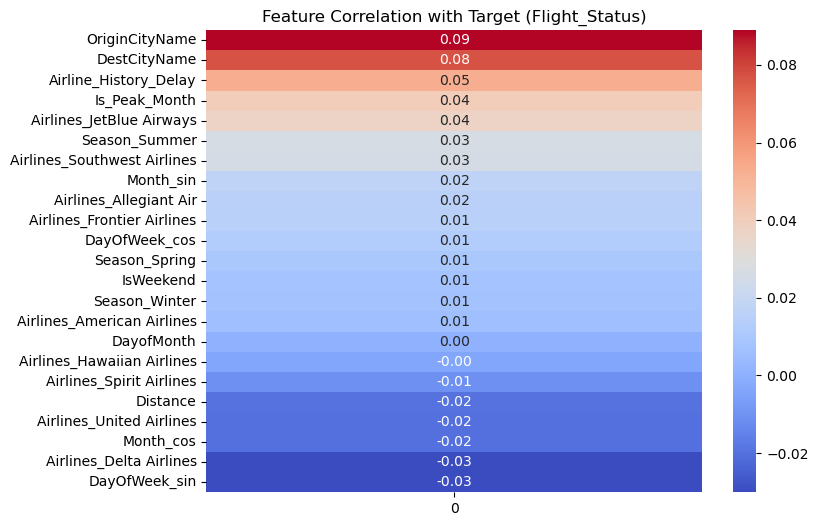

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = x_train.select_dtypes(include=['int64','float64']).columns
corr_target = x_train[numeric_cols].corrwith(y_train).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.heatmap(corr_target.to_frame(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation with Target (Flight_Status)")
plt.show()


# Scaling⚡

In [90]:
x_train.head()

,DayofMonth,OriginCityName,DestCityName,Distance,IsWeekend,Airline_History_Delay,Is_Peak_Month,Month_sin,Month_cos,DayOfWeek_sin,...,Airlines_Delta Airlines,Airlines_Frontier Airlines,Airlines_Hawaiian Airlines,Airlines_JetBlue Airways,Airlines_Southwest Airlines,Airlines_Spirit Airlines,Airlines_United Airlines,Season_Spring,Season_Summer,Season_Winter
237177,30,0.337075,0.336928,1620.0,1,0.182522,0,5.000000e-01,0.866025,-2.449294e-16,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1268428,21,0.342611,0.188571,270.0,1,0.197524,0,5.000000e-01,-0.866025,-7.818315e-01,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3173195,30,0.237393,0.330562,763.0,0,0.238792,1,-2.449294e-16,1.000000,-9.749279e-01,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1571862,11,0.342611,0.243713,1081.0,1,0.197524,1,1.224647e-16,-1.000000,-7.818315e-01,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1669462,7,0.217155,0.272333,329.0,0,0.182522,0,-5.000000e-01,-0.866025,-4.338837e-01,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [91]:
x_train['OriginCityName'].head()

237177     0.337075
1268428    0.342611
3173195    0.237393
1571862    0.342611
1669462    0.217155
Name: OriginCityName, dtype: float64

In [92]:
x_train['DestCityName'].head()

237177     0.336928
1268428    0.188571
3173195    0.330562
1571862    0.243713
1669462    0.272333
Name: DestCityName, dtype: float64

***
`Standard Scaler`
***

In [93]:
from sklearn.preprocessing import StandardScaler

standard_cols = ['DayofMonth','Year']
standard_scaler = StandardScaler()

x_train[standard_cols] = standard_scaler.fit_transform(x_train[standard_cols])
x_test[standard_cols] = standard_scaler.transform(x_test[standard_cols])


In [120]:
# Save StandardScaler
with open('standard_scaler.pkl', 'wb') as f:
    pickle.dump(standard_scaler, f)
print("✅ StandardScaler saved")

✅ StandardScaler saved


***
`Robust Scaler`
***

In [94]:
from sklearn.preprocessing import RobustScaler

robust_cols = ['Distance']
robust_scaler = RobustScaler()

x_train[robust_cols] = robust_scaler.fit_transform(x_train[robust_cols])
x_test[robust_cols] = robust_scaler.transform(x_test[robust_cols])

In [121]:
# Save RobustScaler
with open('robust_scaler.pkl', 'wb') as f:
    pickle.dump(robust_scaler, f)
print("✅ RobustScaler saved")

✅ RobustScaler saved


In [95]:
x_train.head()

,DayofMonth,OriginCityName,DestCityName,Distance,IsWeekend,Airline_History_Delay,Is_Peak_Month,Month_sin,Month_cos,DayOfWeek_sin,...,Airlines_Delta Airlines,Airlines_Frontier Airlines,Airlines_Hawaiian Airlines,Airlines_JetBlue Airways,Airlines_Southwest Airlines,Airlines_Spirit Airlines,Airlines_United Airlines,Season_Spring,Season_Summer,Season_Winter
237177,1.629215,0.337075,0.336928,1.261803,1,0.182522,0,5.000000e-01,0.866025,-2.449294e-16,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1268428,0.601407,0.342611,0.188571,-0.669528,1,0.197524,0,5.000000e-01,-0.866025,-7.818315e-01,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3173195,1.629215,0.237393,0.330562,0.035765,0,0.238792,1,-2.449294e-16,1.000000,-9.749279e-01,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1571862,-0.540601,0.342611,0.243713,0.490701,1,0.197524,1,1.224647e-16,-1.000000,-7.818315e-01,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1669462,-0.997404,0.217155,0.272333,-0.585122,0,0.182522,0,-5.000000e-01,-0.866025,-4.338837e-01,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


## Handling Imbalanced Data ⚖️

### Smoting

In [99]:
'''
from imblearn.over_sampling import SMOTE
smote=SMOTE(k_neighbors=5,random_state=48)
x_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)
'''


'\nfrom imblearn.over_sampling import SMOTE\nsmote=SMOTE(k_neighbors=5,random_state=48)\nx_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)\n'

## 🔄 Random Under-Sampling

**🎯 Goal:** Balance the dataset by **reducing the size of the majority class** so the model sees **equal representation** of all classes.  

**⚙️ How it works:**  
- The majority class samples are randomly removed until it **matches the minority class size**.  
- Keeps the dataset smaller and training faster.  

**📊 Example Distribution:**  
- **Before:** 1,870,482 (class 0) vs 776,584 (class 1)  
- **After:** 776,584 (class 0) vs 776,584 (class 1) ✅

**💡 Note:** Useful for **imbalanced datasets** where one class dominates, preventing the model from being biased.  

In [100]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(sampling_strategy='auto', random_state=48)

x_train_under, y_train_under = rus.fit_resample(x_train, y_train)

print("Before:", y_train.value_counts())
print("After:", y_train_under.value_counts())


Before: Flight_Status
0    1870482
1     776584
Name: count, dtype: int64
After: Flight_Status
0    776584
1    776584
Name: count, dtype: int64


# Modeling🧠

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_auc_score,roc_curve,
    precision_recall_curve,average_precision_score
)
# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier


***
`LogisticRegression`
***

In [102]:
model1=LogisticRegression()
model1.fit(x_train,y_train)

LogisticRegression()

In [103]:
y_pred1=model1.predict(x_test)

In [104]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.71      1.00      0.83    467621
           1       0.45      0.00      0.01    194146

    accuracy                           0.71    661767
   macro avg       0.58      0.50      0.42    661767
weighted avg       0.63      0.71      0.59    661767



In [105]:
model1=LogisticRegression()
model1.fit(x_train_under,y_train_under)

LogisticRegression()

In [106]:
y_pred1=model1.predict(x_test)

In [107]:
print(classification_report(y_test,y_pred1))


              precision    recall  f1-score   support

           0       0.76      0.55      0.64    467621
           1       0.35      0.58      0.43    194146

    accuracy                           0.56    661767
   macro avg       0.55      0.56      0.53    661767
weighted avg       0.64      0.56      0.58    661767



***
`RandomForest`
***

In [108]:
model2=RandomForestClassifier()
model2.fit(x_train_under,y_train_under)

RandomForestClassifier()

In [109]:
y_pred2=model2.predict(x_test)

In [110]:
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.69      0.49      0.57    467621
           1       0.28      0.47      0.35    194146

    accuracy                           0.48    661767
   macro avg       0.48      0.48      0.46    661767
weighted avg       0.57      0.48      0.51    661767



***
`xgboost`
***

In [111]:
model3=XGBClassifier()
model3.fit(x_train_under,y_train_under)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [112]:
y_pred3=model3.predict(x_test)

In [113]:
print(classification_report(y_test,y_pred3))

              precision    recall  f1-score   support

           0       0.79      0.59      0.68    467621
           1       0.39      0.62      0.48    194146

    accuracy                           0.60    661767
   macro avg       0.59      0.61      0.58    661767
weighted avg       0.67      0.60      0.62    661767



In [114]:
from xgboost import XGBClassifier

model7 = XGBClassifier(
    n_estimators=300,      
    max_depth=7,           
    learning_rate=0.05,    
    subsample=0.8,         
    colsample_bytree=0.8,  
    random_state=48,
    use_label_encoder=False,
    eval_metric='logloss'
)


model7.fit(x_train_under, y_train_under)
y_pred7=model7.predict(x_test)

print(classification_report(y_test,y_pred7))


              precision    recall  f1-score   support

           0       0.79      0.59      0.68    467621
           1       0.39      0.62      0.48    194146

    accuracy                           0.60    661767
   macro avg       0.59      0.61      0.58    661767
weighted avg       0.67      0.60      0.62    661767



In [122]:
# ---- Save the trained model ----
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(model7, f)

print("✅ XGBClassifier saved successfully as 'xgb_model.pkl'")

✅ XGBClassifier saved successfully as 'xgb_model.pkl'


***
`CatBoost`
***

In [115]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

cat_model = CatBoostClassifier(
    iterations=500,       
    learning_rate=0.1,    
    depth=6,              
    verbose=100,          
    random_state=48
)


cat_model.fit(x_train_under, y_train_under)


y_pred_cat = cat_model.predict(x_test)

print(classification_report(y_test,y_pred_cat))

0:	learn: 0.6915261	total: 247ms	remaining: 2m 3s
100:	learn: 0.6705359	total: 8.45s	remaining: 33.4s
200:	learn: 0.6666791	total: 17.4s	remaining: 25.9s
300:	learn: 0.6642122	total: 26.8s	remaining: 17.7s
400:	learn: 0.6624198	total: 36.8s	remaining: 9.09s
499:	learn: 0.6609408	total: 47.2s	remaining: 0us
              precision    recall  f1-score   support

           0       0.79      0.59      0.67    467621
           1       0.38      0.61      0.47    194146

    accuracy                           0.60    661767
   macro avg       0.58      0.60      0.57    661767
weighted avg       0.67      0.60      0.61    661767



In [ ]:
models = {

    # Linear
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=1),

    # Distance-based
    #"KNN": KNeighborsClassifier(n_neighbors=5),

    # SVM
    #"SVC": SVC(probability=True, random_state=1),

    # Tree
    "Decision Tree": DecisionTreeClassifier(random_state=1),

    # Naive Bayes
    "Naive Bayes": GaussianNB(),

    # Bagging Based
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=1),

    # Boosting
    "AdaBoost": AdaBoostClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=1),

    # External Boosting Libraries
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=1, use_label_encoder=False),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=1),
    "LightGBM": LGBMClassifier(random_state=1)
}

In [91]:
import pandas as pd

df_under = pd.concat([x_train_under, y_train_under], axis=1)

class_0 = df_under[df_under['Flight_Status'] == 0].sample(n=150000, random_state=48)
class_1 = df_under[df_under['Flight_Status'] == 1].sample(n=150000, random_state=48)

df_small = pd.concat([class_0, class_1]).sample(frac=1, random_state=48)


x_train_small = df_small.drop('Flight_Status', axis=1)
y_train_small = df_small['Flight_Status']

print(y_train_small.value_counts())


Flight_Status
1    150000
0    150000
Name: count, dtype: int64


In [92]:
model3=RandomForestClassifier()
model3.fit(x_train_small,y_train_small)

RandomForestClassifier()

In [93]:
y_pred3=model3.predict(x_test)

In [94]:
print(classification_report(y_test,y_pred3))

              precision    recall  f1-score   support

           0       0.75      0.56      0.64    467621
           1       0.34      0.55      0.42    194146

    accuracy                           0.55    661767
   macro avg       0.54      0.55      0.53    661767
weighted avg       0.63      0.55      0.57    661767



In [95]:
x_train_small.head()

,DayofMonth,OriginCityName,DestCityName,Distance,IsWeekend,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos,Year,...,Airlines_Delta Airlines,Airlines_Frontier Airlines,Airlines_Hawaiian Airlines,Airlines_JetBlue Airways,Airlines_Southwest Airlines,Airlines_Spirit Airlines,Airlines_United Airlines,Season_Spring,Season_Summer,Season_Winter
126230,-1.111687,0.303122,0.257815,-0.813218,0,0.500000,8.660254e-01,-4.338837e-01,-0.900969,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
563166,-1.225891,0.292741,0.284129,-0.563901,1,1.000000,6.123234e-17,-7.818315e-01,0.623490,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
389800,0.943997,0.359919,0.257815,2.102844,0,0.866025,5.000000e-01,-4.338837e-01,-0.900969,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1758121,0.144565,0.359919,0.303771,0.264526,1,-0.500000,-8.660254e-01,-2.449294e-16,1.000000,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2582837,-1.682710,0.273695,0.367458,-0.379280,1,-0.866025,5.000000e-01,-7.818315e-01,0.623490,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [96]:
x_train_small.columns

Index(['DayofMonth', 'OriginCityName', 'DestCityName', 'Distance', 'IsWeekend',
       'Month_sin', 'Month_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Year',
       'Airlines_Allegiant Air', 'Airlines_American Airlines',
       'Airlines_Delta Airlines', 'Airlines_Frontier Airlines',
       'Airlines_Hawaiian Airlines', 'Airlines_JetBlue Airways',
       'Airlines_Southwest Airlines', 'Airlines_Spirit Airlines',
       'Airlines_United Airlines', 'Season_Spring', 'Season_Summer',
       'Season_Winter'],
      dtype='object')

In [ ]:
results = {}

for name, model in tqdm(models.items()):
    model.fit(x_train_smote, y_train_smote)

    train_pred = model.predict(x_train_smote)
    test_pred  = model.predict(x_test)

    results[name] = {
        "Train Accuracy": accuracy_score(y_train_smote, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train Precision": precision_score(y_train_smote, train_pred),
        "Test Precision": precision_score(y_test, test_pred),
        "Train Recall": recall_score(y_train_smote, train_pred),
        "Test Recall": recall_score(y_test, test_pred),
        "Train F1 Score": f1_score(y_train_smote, train_pred),
        "Test F1 Score": f1_score(y_test, test_pred),
        "Train Balanced Accuracy": balanced_accuracy_score(y_train_smote, train_pred),
        "Test Balanced Accuracy": balanced_accuracy_score(y_test, test_pred)

    }

    cm = confusion_matrix(y_test, test_pred)
    print("\nConfusion Matrix:\n", cm)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm,annot=True,fmt="d",cmap='Blues',cbar=False,
                xticklabels=['<=50K','>50K']
                ,yticklabels=['<=50K','>50K'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

    # Full classification report
    print("\nClassification Report:\n")
    print(classification_report(y_test, test_pred,target_names=['Not Stroke','Stroke'],zero_division=0))

    y_pred_prob = model.predict_proba(x_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    print("ROC-AUC:", roc_auc)

    # ROC curve
    fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_prob)
    plt.figure()
    plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], 'k--') 
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

    pr_auc = average_precision_score(y_test, y_pred_prob)
    print("PR AUC:", pr_auc)

    precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)
    plt.figure()
    plt.plot(recall_vals, precision_vals, label='Precision-Recall curve')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()
    

In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="Test F1 Score", ascending=False)

In [ ]:
results_df[["Test Accuracy", "Train Accuracy"]].plot.bar(figsize=(12,6))

In [ ]:
cols = [
    ['Train Accuracy', 'Test Accuracy'],
    ['Train Precision', 'Test Precision'],
    ['Train Recall', 'Test Recall'],
    ['Train F1 Score', 'Test F1 Score'],
    ["Train Balanced Accuracy", "Test Balanced Accuracy"]
]

plt.figure(figsize=(30,30))

for i, col in enumerate(cols):
    ax = plt.subplot(3, 2, i+1)   
    results_df[col].plot.bar(ax=ax)   
    ax.set_title(col[0].split(" ")[1] + ' Comparison')

plt.tight_layout()
plt.show()

In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="Test F1 Score", ascending=False)

In [ ]:
results_df

# Hyperparameter Tuning – XGBClassifier 🔍 
- Goal: Find the best parameters for XGBClassifier to maximize accuracy.
- Method: GridSearchCV with cross-validation.

In [157]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV


In [158]:
xg = XGBClassifier(random_state=48)

In [159]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}


In [160]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,                 
    n_jobs=-1,             
    verbose=2,
    scoring='accuracy'     
)


In [ ]:
grid_search.fit(x_train_small, y_train_small)

In [ ]:
print("Best Accuracy:", grid_search.best_score_)
print("Best Parameters:", grid_search.best_params_)